### Data analysis in astronomy at NTU 

Week 4

Ting-Wen Lan 

This notebook is for exploring the correlation coefficients

In [5]:
import numpy as np
import astropy.io.fits as pf
import matplotlib.pyplot as plt
#import healpy as hp
import matplotlib.cm as cm
import scipy.stats as ss

### https://www.dropbox.com/s/h7545q0vzcqhi38/sky_maps_new_64_v6.fits?dl=0

In [6]:
ISM = pf.getdata('/Users/xiechengan/Documents/GitHub/113-1-fall-Data-Analysis-in-Astronomy/Week5/Sky_Maps_v6.fits',1)

In [7]:
EBV = ISM['SFD']
HI = ISM['HI']/1e21

conversion_factor = 2*1e20/1e21
H2 = ISM['CO10']*conversion_factor


<ipython-input-4-0f40923188a6>:3: RuntimeWarning: invalid value encountered in log10
  hp.mollview(np.log10(H2*1e21),min=19,max=22,title='H2',cmap=cm.jet,unit='$log_{10} N_{H2}$')


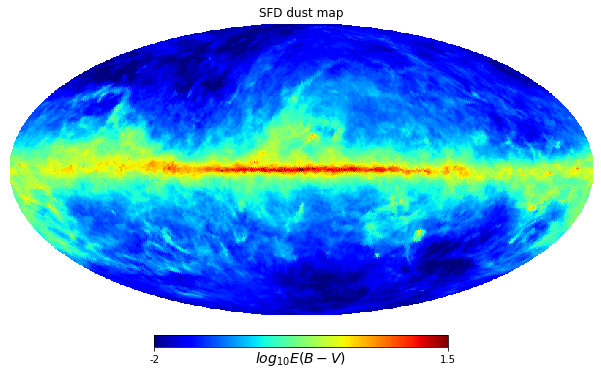

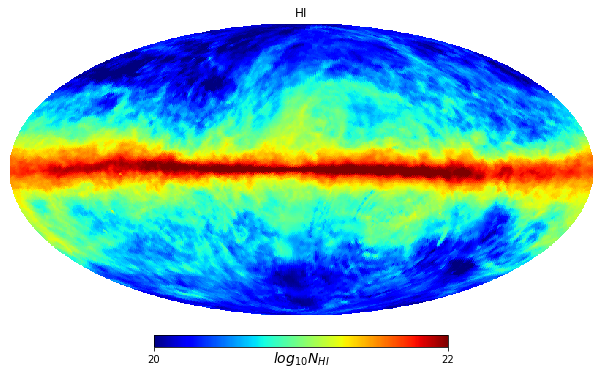

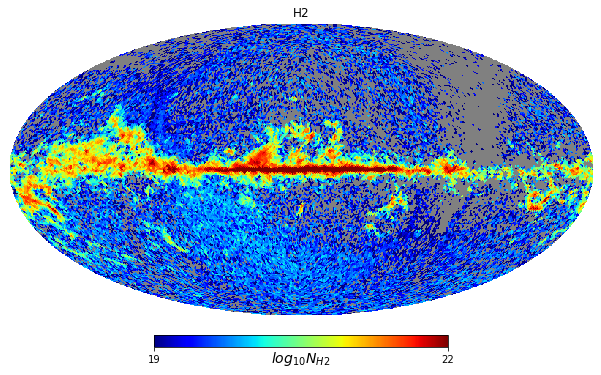

In [4]:
hp.mollview(np.log10(EBV),min=-2,max=1.5,title='SFD dust map',cmap=cm.jet,unit='$log_{10} E(B-V)$')
hp.mollview(np.log10(HI*1e21),min=20,max=22,title='HI',cmap=cm.jet,unit='$log_{10} N_{HI}$')
hp.mollview(np.log10(H2*1e21),min=19,max=22,title='H2',cmap=cm.jet,unit='$log_{10} N_{H2}$')

Text(0, 0.5, '$N_{H2}$ [$10^{21} \\rm cm^{-2}$]')

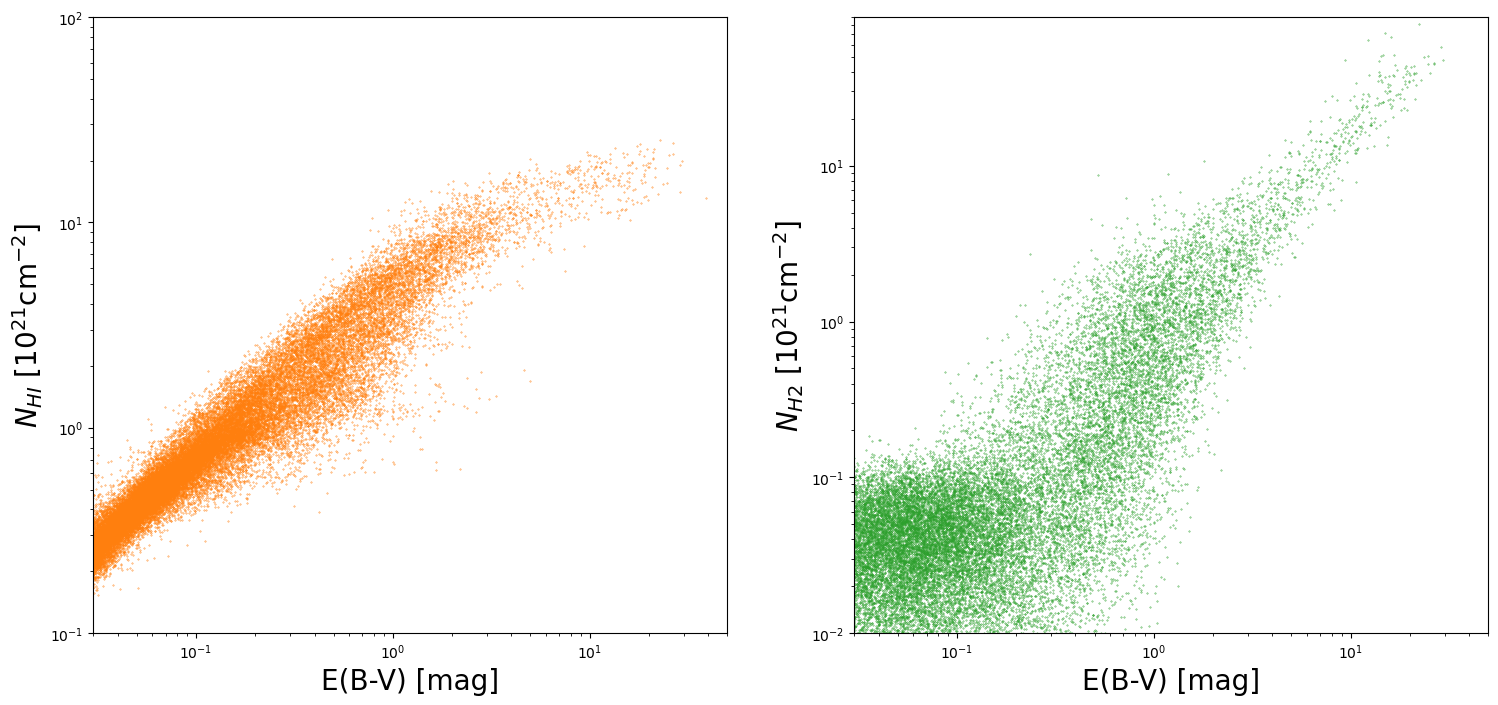

In [10]:
plt.figure(figsize=(18,8))
plt.subplots_adjust(hspace=0)
plt.subplot(1,2,1)

plt.scatter(EBV,HI,s=0.1,c='C1')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.03,50)
plt.xlabel('E(B-V) [mag]',fontsize=20)
plt.ylim(0.1,100)
plt.ylabel('$N_{HI}$ [$10^{21} \\rm cm^{-2}$]',fontsize=20)




plt.subplot(1,2,2)
plt.scatter(EBV,H2,s=0.1,c='C2')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.03,50)
plt.ylim(0.01,90)
plt.xlabel('E(B-V) [mag]',fontsize=20)
plt.ylabel('$N_{H2}$ [$10^{21} \\rm cm^{-2}$]',fontsize=20)

# Exercise 1 Pearson correlation coefficient

### https://www.dropbox.com/s/h7545q0vzcqhi38/sky_maps_new_64_v6.fits?dl=0
### 1. Write your own code to calculate Pearson correlation coefficient between (EBV, HI) (EBV, H2)
### 2. Using boostrap to estimate the uncertainty
### 3. Compare the coefficient from your code and from scipy.stats.pearsonr

In [8]:
EBV = ISM['SFD']
HI = ISM['HI']/1e21

conversion_factor = 2*1e20/1e21 ### A factor to convert CO to H2
H2 = ISM['CO10']*conversion_factor

In [9]:
from scipy.optimize import curve_fit

def your_pearsonr(x,y):
    
    ### Your code here
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    nx = len(x)
    ny = len(y)
    cov = np.sum((x - x_mean)*(y - y_mean))/(nx-1)

    if nx != ny:
        raise ValueError("x and y must have the same length")
    
    r = cov / (x_std * y_std)
    
    return  r

r = your_pearsonr(EBV,HI)
r2 = your_pearsonr(EBV,H2)

r_sci, _ = ss.pearsonr(EBV, HI)
r_sci2, _ = ss.pearsonr(EBV, H2)

print(f'EBV and HI, r = {r}, Scipy = {r_sci}')
print(f'EBV and H2, r = {r2}, Scipy = {r_sci2}')

# Calculate bootstrap for Pearson correlation coefficient
def bootstrap_pearson(x, y, n=1000):
    r_values = []
    for _ in range(n):
        indices = np.random.randint(0, len(x), len(x))
        x_boot = x[indices]
        y_boot = y[indices]    
        r, _ = ss.pearsonr(x_boot, y_boot)
        r_values.append(r)
    return np.std(r_values)

# Calculate bootstrap errors
bootstrap_error_pearson_HI = bootstrap_pearson(EBV, HI)
bootstrap_error_pearson_H2 = bootstrap_pearson(EBV, H2)

print(f'Bootstrap error for Pearson correlation (EBV, HI): {bootstrap_error_pearson_HI}')
print(f'Bootstrap error for Pearson correlation (EBV, H2): {bootstrap_error_pearson_H2}')


# Plotting the fitting line with the scatter plot
plt.figure(figsize=(18,8))
plt.subplots_adjust(hspace=0)

# Plot for EBV vs HI
plt.subplot(1,2,1)
plt.scatter(EBV, HI, s=0.1, c='C1')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.03, 50)
plt.ylim(0.1, 100)
plt.xlabel('E(B-V) [mag]', fontsize=20)
plt.ylabel('$N_{HI}$ [$10^{21} \\rm cm^{-2}$]', fontsize=20)

# Fit line

def linear_func(x, a, b):
    return a * x + b

# Fit line using scipy for EBV vs HI
popt, _ = curve_fit(linear_func, np.log10(EBV), np.log10(HI))
plt.plot(EBV, 10**linear_func(np.log10(EBV), *popt), color='red', linewidth=2)


# Plot for EBV vs H2
# Filter out non-positive values
valid_indices = (EBV > 0) & (H2 > 0)
EBV_valid = EBV[valid_indices]
H2_valid = H2[valid_indices]

plt.subplot(1,2,2)
plt.scatter(EBV_valid, H2_valid, s=0.1, c='C2')
plt.yscale('log')
plt.xscale('log')
plt.xlim(0.03, 50)
plt.ylim(0.01, 90)
plt.xlabel('E(B-V) [mag]', fontsize=20)
plt.ylabel('$N_{H2}$ [$10^{21} \\rm cm^{-2}$]', fontsize=20)

# Fit line using scipy for EBV vs H2
popt2, _ = curve_fit(linear_func, np.log10(EBV_valid), np.log10(H2_valid))
plt.plot(EBV_valid, 10**linear_func(np.log10(EBV_valid), *popt2), color='blue', linewidth=2)

plt.show()

EBV and HI, r = 0.7668488855500266, Scipy = 0.7668333406050061
EBV and H2, r = 0.8651504559122951, Scipy = 0.8651329272353969


KeyboardInterrupt: 

# Exercise 2 Spearman correlation coefficient

### 1. Write your own code to calculate Spearman correlation coefficient between (EBV, HI) (EBV, H2)
### 2. Using boostrap to estimate the uncertainty
### 3. Compare the coefficient from your code and from scipy.stats.spearmanr

In [10]:
def bubble_sorted_index(data):
    new_list = list(data)
    list_len = len(new_list)
    index = list(range(list_len))
    for i in range(list_len-1):
        for j in range(list_len - i - 1):
            if new_list[j] > new_list[j + 1]:
                new_list[j], new_list[j + 1] = new_list[j + 1], new_list[j]
                index[j], index[j + 1] = index[j + 1], index[j]
    return new_list, index


def mergeSort(nums):
    if len(nums) < 2:
        return nums, list(range(len(nums)))
    mid = len(nums) // 2
    left, left_index = mergeSort(nums[:mid])
    right, right_index = mergeSort(nums[mid:])

    i = j = 0
    result = []
    index = []
    while i < len(left) and j < len(right):
        if left[i] < right[j]: 
            result.append(left[i])
            index.append(left_index[i])
            i += 1
        else: 
            result.append(right[j])
            index.append(right_index[j] + mid)
            j += 1

    while i < len(left): 
        result.append(left[i])
        index.append(left_index[i])
        i += 1

    while j < len(right): 
        result.append(right[j])
        index.append(right_index[j] + mid)
        j += 1

    return result, index



def get_rank(data):
    sorted_data, sorted_index = mergeSort(data)
    rank = [0] * len(data)
    for i, idx in enumerate(sorted_index):
        rank[idx] = i + 1
    return rank

# Example usage
rank_HI = get_rank(HI)
rank_EBV = get_rank(EBV)

print(rank_HI)
print(rank_EBV)

def your_spearman(x,y):
    
    ### Your code here
    x_rank = get_rank(x)
    y_rank = get_rank(y)
    x_mean = np.mean(x_rank)
    y_mean = np.mean(y_rank)
    nx = len(x_rank)
    cov_rank = np.sum((x_rank - x_mean)*(y_rank - y_mean))/(nx-1)

    print(cov_rank)
    nx = len(x)
    ny = len(y)
    spearman_correlation_coefficient = cov_rank / (np.std(x_rank) * np.std(y_rank))

    return spearman_correlation_coefficient

print(ss.rankdata(EBV))
print(ss.rankdata(HI))
spearman_HI = your_spearman(EBV, HI)
spearman_H2 = your_spearman(EBV, H2)
print(f'Spearman correlation coefficient (EBV, HI): {spearman_HI}')
print(f'Spearman correlation coefficient (EBV, H2): {spearman_H2}')


[257, 596, 609, 176, 189, 249, 636, 1311, 1770, 945, 111, 163, 359, 284, 435, 974, 1935, 2696, 2028, 2071, 1088, 514, 271, 390, 873, 633, 579, 886, 839, 1602, 2162, 2259, 2932, 2038, 1610, 712, 1719, 1108, 658, 518, 1291, 1166, 1280, 1221, 894, 1209, 2022, 2257, 2368, 2974, 3813, 3250, 1892, 948, 842, 2507, 4109, 4794, 2510, 1365, 2098, 1048, 804, 586, 1286, 1126, 1766, 3195, 2280, 2286, 2856, 3821, 5591, 4466, 3415, 2169, 1712, 1379, 6743, 8738, 9906, 8102, 4304, 2000, 1787, 1951, 716, 776, 582, 840, 1085, 1514, 2724, 2523, 1694, 2150, 3169, 4189, 6331, 5013, 4917, 3113, 3253, 1340, 1484, 9033, 11684, 13015, 12232, 8466, 3692, 1570, 863, 799, 1520, 1297, 968, 778, 630, 1097, 1109, 1376, 1713, 1281, 1900, 1668, 1981, 3243, 5238, 6617, 4717, 5761, 5209, 3235, 1458, 3041, 9067, 12778, 13858, 15975, 13467, 11458, 3493, 1184, 869, 501, 2144, 3209, 2238, 1573, 709, 487, 1445, 1262, 989, 1826, 1565, 2136, 3584, 2719, 1956, 3249, 6398, 8565, 7118, 7616, 6673, 5541, 2996, 2956, 6658, 11425, 11

In [11]:
from astropy.stats import bootstrap

# Bootstrapping

# Calculate bootstrap for Pearson correlation coefficient
def bootstrap_pearson(x, y, n=1000):
    r_values = []
    for _ in range(n):
        indices = np.random.randint(0, len(x), len(x))
        x_boot = x[indices]
        y_boot = y[indices]
        r, _ = ss.pearsonr(x_boot, y_boot)
        r_values.append(r)
    return np.std(r_values)

# Calculate bootstrap for Spearman correlation coefficient
def bootstrap_spearman(x, y, n=1000):
    r_values = []
    for _ in range(n):
        indices = np.random.randint(0, len(x), len(x))
        x_boot = x[indices]
        y_boot = y[indices]
        r, _ = ss.spearmanr(x_boot, y_boot)
        r_values.append(r)
    return np.std(r_values)

# Calculate bootstrap errors
bootstrap_error_pearson_HI = bootstrap_pearson(EBV, HI)
bootstrap_error_pearson_H2 = bootstrap_pearson(EBV, H2)
bootstrap_error_spearman_HI = bootstrap_spearman(EBV, HI)
bootstrap_error_spearman_H2 = bootstrap_spearman(EBV, H2)


print(f'Bootstrap error for Pearson correlation (EBV, HI): {bootstrap_error_pearson_HI}')
print(f'Bootstrap error for Pearson correlation (EBV, H2): {bootstrap_error_pearson_H2}')
print(f'Bootstrap error for Spearman correlation (EBV, HI): {bootstrap_error_spearman_HI}')
print(f'Bootstrap error for Spearman correlation (EBV, H2): {bootstrap_error_spearman_H2}')


    


Bootstrap error for Pearson correlation (EBV, HI): 0.016828658685763925
Bootstrap error for Pearson correlation (EBV, H2): 0.01587346192194272
Bootstrap error for Spearman correlation (EBV, HI): 0.00024777912225478345
Bootstrap error for Spearman correlation (EBV, H2): 0.0047122371378135255


# Exercise 3 Pearson and Spearman correlation coefficient

### Calculate the Pearson and Spearman correlation coefficients with EBV and total H = N_HI + 2xN_H2